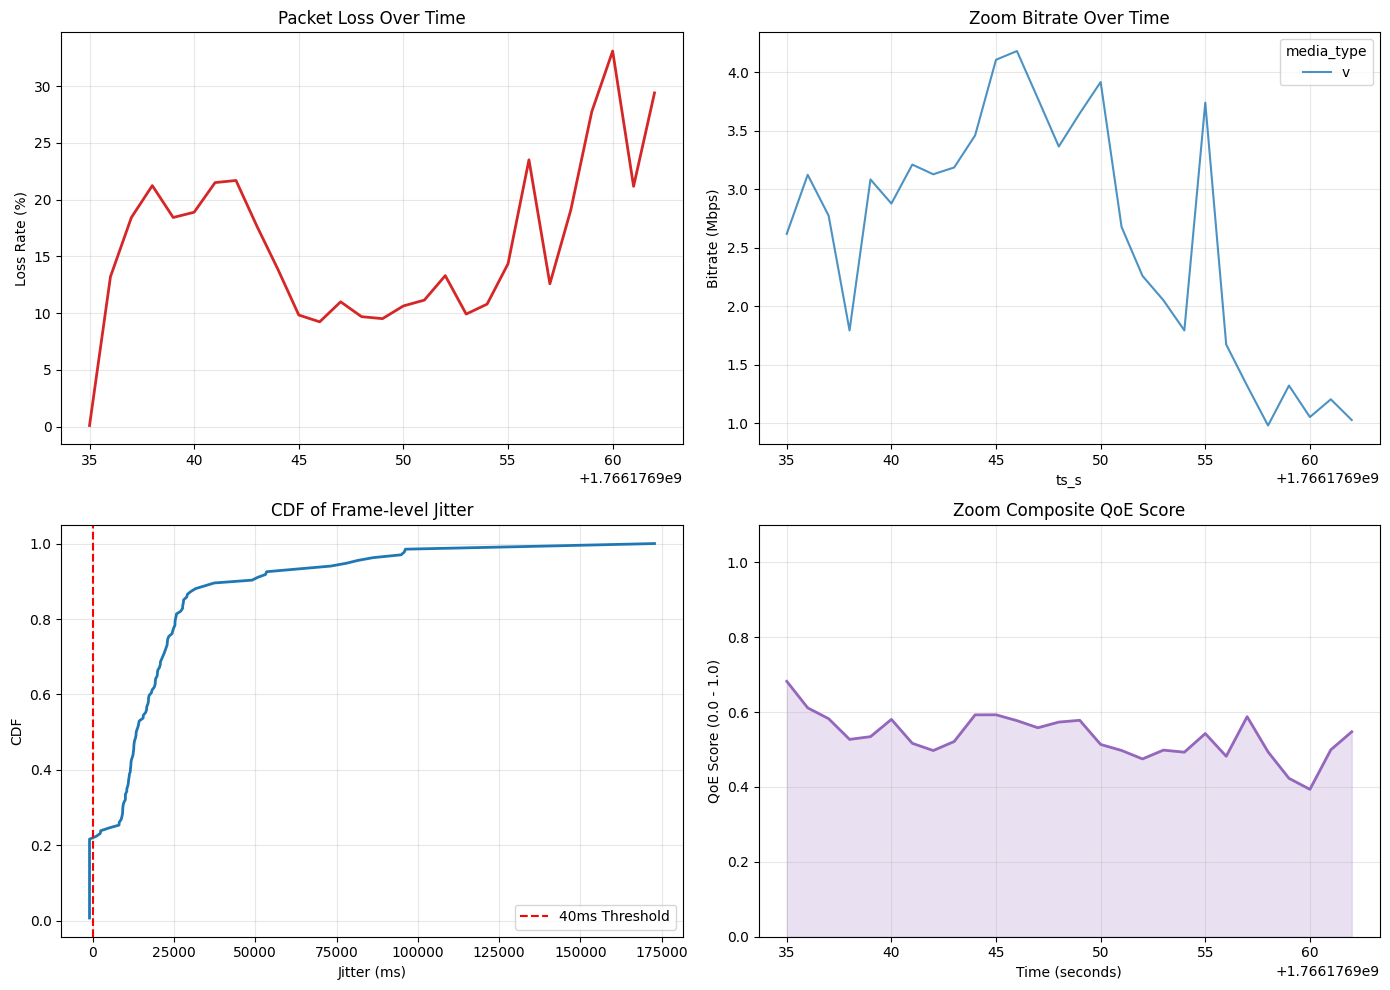

ZOOM QoE PERFORMANCE SUMMARY
Average QoE Score:    0.533 / 1.000
Minimum QoE Score:    0.161
--------------------------------------------------
Avg Loss Rate:        15.90%
Avg Frame Rate:       13.66 FPS
Avg Jitter:           20231.98 ms


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. LOAD AND CLEAN DATA
df = pd.read_csv("stats.csv")
df = df.replace([np.inf, -np.inf], np.nan).fillna(0)

# 2. METRIC CALCULATION
# Loss Rate (0 to 1)
df["loss_rate"] = df["lost"] / (df["pkts"] + df["lost"] + 1e-10)
df["loss_rate"] = df["loss_rate"].clip(0, 1)

# Bitrate (Mbps)
if 'bytes' in df.columns:
    df['bitrate_mbps'] = (df['bytes'] * 8) / 1e6

# Jitter (ms)
if 'mean_jitter' in df.columns:
    df['jitter_ms'] = df['mean_jitter'] * 1000

# 3. QoE SCORE CALCULATION (Based on Image Formula)
# Weights: Adjust these based on your specific requirements (must sum to 1.0)
w1, w2, w3 = 0.4, 0.3, 0.3

# Normalizing FPS: Zoom targets 30 FPS
# We use .clip(0, 1) to ensure the ratio doesn't exceed 1.0 if FPS > 30
df['fps_norm'] = (df['frames'] / 30).clip(0, 1)

# Normalizing Jitter: Threshold is 40ms per the formula
# If jitter is > 40ms, this value becomes 0 (worst quality)
df['jitter_norm'] = (1 - (df['jitter_ms'] / 40)).clip(0, 1)

# Composite QoE Calculation
df['qoe_score'] = (w1 * (1 - df['loss_rate'])) + \
                  (w2 * df['fps_norm']) + \
                  (w3 * df['jitter_norm'])

# Group by second for time-series analysis
qoe_over_time = df.groupby("ts_s")["qoe_score"].mean().reset_index()
loss_over_time = df.groupby("ts_s")["loss_rate"].mean().reset_index()

# 4. PLOTS
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Loss Rate
axes[0,0].plot(loss_over_time['ts_s'], loss_over_time['loss_rate'] * 100, color='#d62728', linewidth=2)
axes[0,0].set_ylabel('Loss Rate (%)')
axes[0,0].set_title('Packet Loss Over Time')
axes[0,0].grid(True, alpha=0.3)

# Plot 2: Bitrate
if 'bitrate_mbps' in df.columns:
    if 'media_type' in df.columns:
        bitrate_by_type = df.groupby(['ts_s', 'media_type'])['bitrate_mbps'].sum().unstack().fillna(0)
        bitrate_by_type.plot(ax=axes[0,1], alpha=0.8)
    else:
        axes[0,1].plot(df.groupby('ts_s')['bitrate_mbps'].sum(), color='#2ca02c')
    axes[0,1].set_ylabel('Bitrate (Mbps)')
    axes[0,1].set_title('Zoom Bitrate Over Time')
    axes[0,1].grid(True, alpha=0.3)

# Plot 3: Jitter CDF
if 'jitter_ms' in df.columns:
    sorted_jitter = np.sort(df['jitter_ms'].dropna())
    cdf = np.arange(1, len(sorted_jitter) + 1) / len(sorted_jitter)
    axes[1,0].plot(sorted_jitter, cdf, color='#1f77b4', linewidth=2)
    axes[1,0].axvline(40, color='red', linestyle='--', label='40ms Threshold')
    axes[1,0].set_xlabel('Jitter (ms)')
    axes[1,0].set_ylabel('CDF')
    axes[1,0].set_title('CDF of Frame-level Jitter')
    axes[1,0].legend()
    axes[1,0].grid(True, alpha=0.3)

# Plot 4: COMPOSITE QoE SCORE (New)
axes[1,1].plot(qoe_over_time['ts_s'], qoe_over_time['qoe_score'], color='#9467bd', linewidth=2)
axes[1,1].fill_between(qoe_over_time['ts_s'], qoe_over_time['qoe_score'], alpha=0.2, color='#9467bd')
axes[1,1].set_ylabel('QoE Score (0.0 - 1.0)')
axes[1,1].set_xlabel('Time (seconds)')
axes[1,1].set_title('Zoom Composite QoE Score')
axes[1,1].set_ylim(0, 1.1)
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('zoom_qoe_analysis.png', dpi=150)
plt.show()

# 5. ENHANCED SUMMARY STATISTICS
print("=" * 50)
print("ZOOM QoE PERFORMANCE SUMMARY")
print("=" * 50)
print(f"Average QoE Score:    {df['qoe_score'].mean():.3f} / 1.000")
print(f"Minimum QoE Score:    {df['qoe_score'].min():.3f}")
print("-" * 50)
print(f"Avg Loss Rate:        {df['loss_rate'].mean()*100:.2f}%")
print(f"Avg Frame Rate:       {df['frames'].mean():.2f} FPS")
print(f"Avg Jitter:           {df['jitter_ms'].mean():.2f} ms")
print("=" * 50)

# Save full results
df.to_csv("detailed_qoe_results.csv", index=False)




# 1. try different network 